In [28]:
from pynq import Overlay, DefaultIP, MMIO, allocate 
import numpy as np
from enum import Enum
import time
import struct
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BRAM_ADDR = 0x80010000
ADDRESS_RANGE = 0x1000
ADDRESS_OFFSET = 0x00
bram = MMIO(BRAM_ADDR,ADDRESS_RANGE)
NUM_TAPS_OFFSET = 0x0
LOWER_CUTOFF_OFFSET = 0x4
UPPER_CUTOFF_OFFSET = 0x8
SAMPLING_RATE_OFFSET = 0xC
READ_SUCCESS_OFFSET = 0x10
RESET_OFFSET = 0x14

MAX_AMP = 32767 // 2 
V_HIGH  = 3.3
PERIOD  = 0.01        # 10ms period
FS      = 100000      # samples/sec

def plot_pwm(input_val):
    duty = min(input_val / MAX_AMP, 1.0)
    duty_pct = duty * 100
    avg_v = duty * V_HIGH

    # Build one period of PWM
    t = np.linspace(0, PERIOD, int(FS * PERIOD), endpoint=False)
    on_samples = int(duty * len(t))
    pwm = np.zeros(len(t))
    pwm[:on_samples] = V_HIGH

    # Repeat for 3 periods
    t_full   = np.concatenate([t + i * PERIOD for i in range(3)])
    pwm_full = np.tile(pwm, 3)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.step(t_full * 1000, pwm_full, where='post', color='#1D9E75', linewidth=2)
    ax.fill_between(t_full * 1000, pwm_full, step='post', alpha=0.15, color='#1D9E75')
    ax.axhline(avg_v, color='#D85A30', linewidth=1.2, linestyle='--', label=f'Avg voltage: {avg_v:.2f} V')

    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title(f'PWM Signal  |  Input: {input_val}  |  Duty cycle: {duty_pct:.1f}%  |  Avg: {avg_v:.2f} V')
    ax.set_ylim(-0.4, 4.0)
    ax.set_yticks([0, V_HIGH])
    ax.set_yticklabels(['0 V', '3.3 V'])
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
def plot_array(arr, fs):
    """
    arr: input signal
    fs: sampling frequency (samples per second)
    """
    N = len(arr)
    t = np.arange(N) / fs  # convert index → time

    plt.figure()
    plt.plot(t, arr)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Signal vs Time")
    plt.grid()
    plt.show() 
    
def hex(val):
    return f"0x{val:08X}"

        
class AddDriver(DefaultIP):
    bindto = ['xilinx.com:hls:firFilter:1.0']

    def process(self):
        self.write(0x10, BRAM_ADDR)
        print(hex(self.read(0x10)))

#load overlay
overlay = Overlay('motor_sim.bit')
add_ip = overlay.firFilter
add_ip.write(0x10, BRAM_ADDR)

#add dma
dma = overlay.axi_dma 
dma_send = overlay.axi_dma.sendchannel 
dma_recv = overlay.axi_dma.recvchannel 

def set_bram_data(numTaps, lowerCutoff, upperCutoff, samplingRate):
    bram.write(NUM_TAPS_OFFSET, numTaps)
    bram.write(LOWER_CUTOFF_OFFSET, lowerCutoff)
    bram.write(UPPER_CUTOFF_OFFSET, upperCutoff)
    bram.write(SAMPLING_RATE_OFFSET, samplingRate)
    bram.write(READ_SUCCESS_OFFSET, 0)

def isFirReadingMem():
    return bram.read(READ_SUCCESS_OFFSET)

def resetSystem(): 
    bram.write(RESET_OFFSET, 0x1)

def generate_sine_samples(freq=100, sample_rate=100000, num_samples=100):
    t = np.linspace(0, num_samples/sample_rate, num_samples)
    sine = np.sin(2 * np.pi * freq * t)
    return (sine * 32767).astype(np.int32)

def stream(integerList):
    CONTROL_REGISTER = 0x0 
    data_size = 1000
    input_buffer = allocate(shape=(data_size,), dtype=np.int32) 
    for i in range(len(integerList)): 
        input_buffer[i] = integerList[i]
    dma_send.transfer(input_buffer) 
    output_buffer = allocate(shape=(data_size,), dtype=np.int32) 
    dma_recv.transfer(output_buffer)
    for i in range(len(integerList)): 
        integerList[i] = output_buffer[i] 
    del input_buffer, output_buffer 
    return integerList


In [29]:
set_bram_data(101, 2000, 5000, 100000)
isFirReadingMem()


0

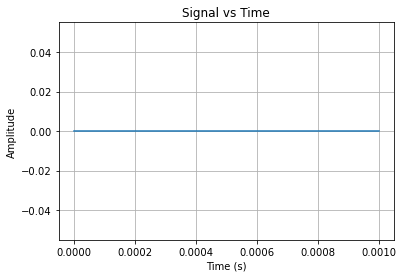

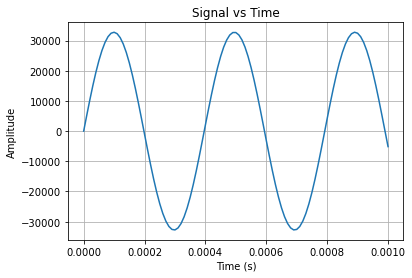

In [30]:
fs = 100000
sample1 = generate_sine_samples(0, fs,101)
sample2 = generate_sine_samples(2500, fs,101)
plot_array(sample1, fs)
plot_array(sample2, fs)
#print(sample2)
resetSystem()
#print(sample)

[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  1  1  2  2  3  3  4  4
  5  6  7  8  9 11 12 14 17 19 21 23 26 28 30 31 33 33 33 32 30 28 25 21
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0]


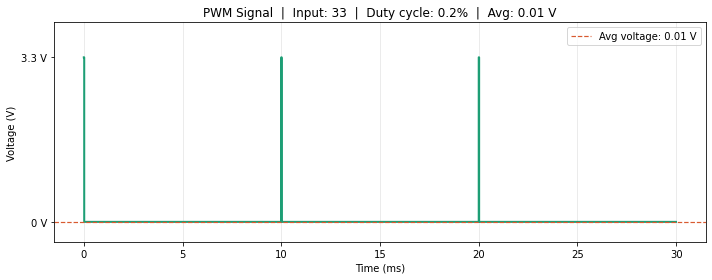

In [18]:
#print(isFirReadingMem())
sample_out = stream(sample1)
print(sample_out)
plot_pwm(max(sample_out))


In [101]:
overlay.ip_dict

{'axi_dma': {'type': 'xilinx.com:ip:axi_dma:7.1',
  'mem_id': 'S_AXI_LITE',
  'memtype': 'REGISTER',
  'gpio': {},
  'interrupts': {},
  'parameters': {'C_DLYTMR_RESOLUTION': '125',
   'C_ENABLE_MULTI_CHANNEL': '0',
   'C_FAMILY': 'zynquplus',
   'C_INCLUDE_MM2S': '1',
   'C_INCLUDE_MM2S_DRE': '0',
   'C_INCLUDE_MM2S_SF': '1',
   'C_INCLUDE_S2MM': '1',
   'C_INCLUDE_S2MM_DRE': '0',
   'C_INCLUDE_S2MM_SF': '1',
   'C_INCLUDE_SG': '0',
   'C_INCREASE_THROUGHPUT': '0',
   'C_MICRO_DMA': '0',
   'C_MM2S_BURST_SIZE': '16',
   'C_M_AXIS_MM2S_CNTRL_TDATA_WIDTH': '32',
   'C_M_AXIS_MM2S_TDATA_WIDTH': '32',
   'C_M_AXI_MM2S_ADDR_WIDTH': '64',
   'C_M_AXI_MM2S_DATA_WIDTH': '64',
   'C_M_AXI_S2MM_ADDR_WIDTH': '64',
   'C_M_AXI_S2MM_DATA_WIDTH': '32',
   'C_M_AXI_SG_ADDR_WIDTH': '64',
   'C_M_AXI_SG_DATA_WIDTH': '32',
   'C_NUM_MM2S_CHANNELS': '1',
   'C_NUM_S2MM_CHANNELS': '1',
   'C_PRMRY_IS_ACLK_ASYNC': '0',
   'C_S2MM_BURST_SIZE': '16',
   'C_SG_INCLUDE_STSCNTRL_STRM': '0',
   'C_SG_LENGTH_WID

In [3]:
print(overlay.ip_dict.keys())

dict_keys(['axi_dma', 'firFilter', 'zynq_ultra_ps_e_0'])
